In [ ]:
import zipfile
import os

ZIP_PATH = "/content/drive/MyDrive/archive (1).zip"
EXTRACT_PATH = "/content/drive/MyDrive/DR_DATA"

# Create extract directory
os.makedirs(EXTRACT_PATH, exist_ok=True)

# Unzip
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("✅ Dataset extracted to:", EXTRACT_PATH)

# Show directory tree (1 level)
for root, dirs, files in os.walk(EXTRACT_PATH):
    print("📂", root)
    for d in dirs:
        print("   ├──", d)
    break


✅ Dataset extracted to: /content/drive/MyDrive/DR_DATA
📂 /content/drive/MyDrive/DR_DATA
   ├── test_images
   ├── train_images
   ├── val_images


In [ ]:
import os
import pandas as pd

BASE_PATH = "/content/drive/MyDrive/DR_DATA"

# ---------- PATHS ----------
TRAIN_IMG_DIR = os.path.join(BASE_PATH, "train_images", "train_images")
VAL_IMG_DIR   = os.path.join(BASE_PATH, "val_images", "val_images")
TEST_IMG_DIR  = os.path.join(BASE_PATH, "test_images", "test_images")

TRAIN_CSV = os.path.join(BASE_PATH, "train_1.csv")
VAL_CSV   = os.path.join(BASE_PATH, "valid.csv")
TEST_CSV  = os.path.join(BASE_PATH, "test.csv")

# ---------- IMAGE COUNTS ----------
def count_images(folder):
    return len([f for f in os.listdir(folder) if f.endswith(".png")])

print("📸 IMAGE COUNTS")
print("Train images:", count_images(TRAIN_IMG_DIR))
print("Val images  :", count_images(VAL_IMG_DIR))
print("Test images :", count_images(TEST_IMG_DIR))
print("Total images:",
      count_images(TRAIN_IMG_DIR) +
      count_images(VAL_IMG_DIR) +
      count_images(TEST_IMG_DIR)
)

# ---------- CSV LOAD ----------
train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

print("\n📄 CSV ROW COUNTS")
print("Train CSV rows:", len(train_df))
print("Val CSV rows  :", len(val_df))
print("Test CSV rows :", len(test_df))

# ---------- CSV STRUCTURE ----------
print("\n🧾 TRAIN CSV COLUMNS:", train_df.columns.tolist())
print("🧾 VAL CSV COLUMNS  :", val_df.columns.tolist())
print("🧾 TEST CSV COLUMNS :", test_df.columns.tolist())

# ---------- CLASS DISTRIBUTION ----------
if "diagnosis" in train_df.columns:
    print("\n📊 TRAIN CLASS DISTRIBUTION")
    print(train_df["diagnosis"].value_counts().sort_index())

if "diagnosis" in val_df.columns:
    print("\n📊 VAL CLASS DISTRIBUTION")
    print(val_df["diagnosis"].value_counts().sort_index())

# ---------- IMAGE–CSV CONSISTENCY CHECK ----------
def missing_images(df, img_dir):
    img_set = set(os.listdir(img_dir))
    csv_imgs = set(df["id_code"] + ".png")
    return csv_imgs - img_set

print("\n❗ MISSING IMAGES CHECK")
print("Missing in TRAIN folder:", len(missing_images(train_df, TRAIN_IMG_DIR)))
print("Missing in VAL folder  :", len(missing_images(val_df, VAL_IMG_DIR)))


📸 IMAGE COUNTS
Train images: 2930
Val images  : 366
Test images : 366
Total images: 3662

📄 CSV ROW COUNTS
Train CSV rows: 2930
Val CSV rows  : 366
Test CSV rows : 366

🧾 TRAIN CSV COLUMNS: ['id_code', 'diagnosis']
🧾 VAL CSV COLUMNS  : ['id_code', 'diagnosis']
🧾 TEST CSV COLUMNS : ['id_code', 'diagnosis']

📊 TRAIN CLASS DISTRIBUTION
diagnosis
0    1434
1     300
2     808
3     154
4     234
Name: count, dtype: int64

📊 VAL CLASS DISTRIBUTION
diagnosis
0    172
1     40
2    104
3     22
4     28
Name: count, dtype: int64

❗ MISSING IMAGES CHECK
Missing in TRAIN folder: 0
Missing in VAL folder  : 0


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

# =========================
# PATHS
# =========================
BASE_PATH = "/content/drive/MyDrive/DR_DATA"
OUT_PATH  = "/content/drive/MyDrive/DR_PROCESSED/train"

os.makedirs(OUT_PATH, exist_ok=True)

CSV_PATH = os.path.join(BASE_PATH, "train_1.csv")
IMG_DIR  = os.path.join(BASE_PATH, "train_images", "train_images")

IMG_SIZE = 224

# =========================
# LOAD CSV
# =========================
df = pd.read_csv(CSV_PATH)

images = []
labels = []

def preprocess(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.astype(np.float32) / 255.0
    return img

# =========================
# PROCESS TRAIN IMAGES
# =========================
for _, row in tqdm(df.iterrows(), total=len(df)):
    img_path = os.path.join(IMG_DIR, row["id_code"] + ".png")
    img = preprocess(img_path)
    images.append(img)
    labels.append(row["diagnosis"])

X = np.array(images, dtype=np.float32)
y = np.array(labels, dtype=np.int64)

print("Train tensor shape:", X.shape)
print("Train labels shape:", y.shape)

# =========================
# SAVE
# =========================
np.save(os.path.join(OUT_PATH, "images.npy"), X)
np.save(os.path.join(OUT_PATH, "labels.npy"), y)

print("✅ TRAIN preprocessing saved to:", OUT_PATH)


100%|██████████| 2930/2930 [06:48<00:00,  7.17it/s]


Train tensor shape: (2930, 224, 224, 3)
Train labels shape: (2930,)
✅ TRAIN preprocessing saved to: /content/drive/MyDrive/DR_PROCESSED/train


In [ ]:
import numpy as np
import os
from collections import Counter
from imblearn.over_sampling import SMOTE

# =========================
# PATHS
# =========================
IN_PATH  = "/content/drive/MyDrive/DR_PROCESSED/train"
OUT_PATH = "/content/drive/MyDrive/DR_PROCESSED_SMOTE/train"

os.makedirs(OUT_PATH, exist_ok=True)

# =========================
# LOAD DATA
# =========================
X = np.load(os.path.join(IN_PATH, "images.npy"))
y = np.load(os.path.join(IN_PATH, "labels.npy"))

print("Original shape:", X.shape, y.shape)
print("Original class distribution:", Counter(y))

# =========================
# FLATTEN
# =========================
N, H, W, C = X.shape
X_flat = X.reshape(N, -1)

print("Flattened shape:", X_flat.shape)

# =========================
# SMOTE (paper-style)
# =========================
smote = SMOTE(
    sampling_strategy="auto",
    random_state=42
)

X_smote, y_smote = smote.fit_resample(X_flat, y)

print("After SMOTE shape:", X_smote.shape, y_smote.shape)
print("After SMOTE class distribution:", Counter(y_smote))

# =========================
# RESHAPE BACK
# =========================
X_smote = X_smote.reshape(-1, H, W, C)

# =========================
# SHUFFLE
# =========================
perm = np.random.permutation(len(y_smote))
X_smote = X_smote[perm]
y_smote = y_smote[perm]

# =========================
# SAVE
# =========================
np.save(os.path.join(OUT_PATH, "images.npy"), X_smote.astype(np.float32))
np.save(os.path.join(OUT_PATH, "labels.npy"), y_smote.astype(np.int64))

print("✅ SMOTE-balanced train set saved to:", OUT_PATH)


Original shape: (2930, 224, 224, 3) (2930,)
Original class distribution: Counter({np.int64(0): 1434, np.int64(2): 808, np.int64(1): 300, np.int64(4): 234, np.int64(3): 154})
Flattened shape: (2930, 150528)
After SMOTE shape: (7170, 150528) (7170,)
After SMOTE class distribution: Counter({np.int64(2): 1434, np.int64(1): 1434, np.int64(4): 1434, np.int64(0): 1434, np.int64(3): 1434})
✅ SMOTE-balanced train set saved to: /content/drive/MyDrive/DR_PROCESSED_SMOTE/train


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

# =========================
# PATHS
# =========================
BASE_PATH = "/content/drive/MyDrive/DR_DATA"
OUT_PATH  = "/content/drive/MyDrive/DR_PROCESSED/val"

os.makedirs(OUT_PATH, exist_ok=True)

CSV_PATH = os.path.join(BASE_PATH, "valid.csv")
IMG_DIR  = os.path.join(BASE_PATH, "val_images", "val_images")

IMG_SIZE = 224

# =========================
# LOAD CSV
# =========================
df = pd.read_csv(CSV_PATH)

images = []
labels = []

def preprocess(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.astype(np.float32) / 255.0
    return img

# =========================
# PROCESS VAL IMAGES
# =========================
for _, row in tqdm(df.iterrows(), total=len(df)):
    img_path = os.path.join(IMG_DIR, row["id_code"] + ".png")
    img = preprocess(img_path)
    images.append(img)
    labels.append(row["diagnosis"])

X = np.array(images, dtype=np.float32)
y = np.array(labels, dtype=np.int64)

print("Val tensor shape:", X.shape)
print("Val labels shape:", y.shape)

# =========================
# SAVE
# =========================
np.save(os.path.join(OUT_PATH, "images.npy"), X)
np.save(os.path.join(OUT_PATH, "labels.npy"), y)

print("✅ VAL preprocessing saved to:", OUT_PATH)


100%|██████████| 366/366 [00:58<00:00,  6.25it/s]


Val tensor shape: (366, 224, 224, 3)
Val labels shape: (366,)
✅ VAL preprocessing saved to: /content/drive/MyDrive/DR_PROCESSED/val


New Start

In [ ]:
import pandas as pd

label_map = {
    0: "No_DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferative"
}

train_df = pd.read_csv("/content/drive/MyDrive/CVPR/DATA_RAW/train_1.csv")
train_df['class_name'] = train_df['diagnosis'].map(label_map)
train_df['class_name'].value_counts()


,count
class_name,
No_DR,1434
Moderate,808
Mild,300
Proliferative,234
Severe,154


In [ ]:
val_df = pd.read_csv("/content/drive/MyDrive/CVPR/DATA_RAW/valid.csv")
val_df['class_name'] = val_df['diagnosis'].map(label_map)
val_df['class_name'].value_counts()


,count
class_name,
No_DR,172
Moderate,104
Mild,40
Proliferative,28
Severe,22


In [ ]:
test_df = pd.read_csv("/content/drive/MyDrive/CVPR/DATA_RAW/test.csv")
test_df['class_name'] = test_df['diagnosis'].map(label_map)
test_df['class_name'].value_counts()


,count
class_name,
No_DR,199
Moderate,87
Proliferative,33
Mild,30
Severe,17


In [ ]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE


In [ ]:
train_df = pd.read_csv("/content/drive/MyDrive/CVPR/DATA_RAW/train_1.csv")
val_df   = pd.read_csv("/content/drive/MyDrive/CVPR/DATA_RAW/valid.csv")
test_df  = pd.read_csv("/content/drive/MyDrive/CVPR/DATA_RAW/test.csv")


In [ ]:
import cv2
import os

def load_flatten_images(df, img_dir, img_size=(224,224)):
    X = []
    y = df['diagnosis'].values

    for img_id in df['id_code']:
        img_path = os.path.join(img_dir, img_id + ".png")
        img = cv2.imread(img_path)
        img = cv2.resize(img, img_size)
        img = img / 255.0
        X.append(img.flatten())

    return np.array(X), y


In [ ]:
import os, cv2
import numpy as np
import pandas as pd
from imblearn.over_sampling import SMOTE

def load_flatten_images_64(df, img_dir, img_size=(64,64)):
    X, y = [], df['diagnosis'].values
    for img_id in df['id_code']:
        p = os.path.join(img_dir, img_id + ".png")
        img = cv2.imread(p)
        img = cv2.resize(img, img_size)
        img = img.astype(np.float32) / 255.0
        X.append(img.flatten())
    return np.array(X), y


In [ ]:
train_df.head()


,id_code,diagnosis
0,1ae8c165fd53,2
1,1b329a127307,1
2,1b32e1d775ea,4
3,1b3647865779,0
4,1b398c0494d1,0


In [ ]:
import os

os.listdir("/content/drive/MyDrive/CVPR/DATA_RAW/train_images/train_images")[:10]


['a12ca80bb8c7.png',
 'a14bbd9a583e.png',
 'a14fcf84bfe1.png',
 'a150ff5dfe07.png',
 'a15470303941.png',
 'a15590a7d774.png',
 'a15652b22ab8.png',
 'a1822dd8d05d.png',
 'a182b5b191de.png',
 'a1872f9c0cba.png']

In [ ]:
def load_flatten_images_64(df, img_dir, img_size=(64,64)):
    X, y = [], []

    for _, row in df.iterrows():
        img_id = row["id_code"]   # ← যদি অন্য column হয়, এখানেই বদলাবে
        label  = row["diagnosis"]

        # try both extensions
        p_png = os.path.join(img_dir, img_id + ".png")
        p_jpg = os.path.join(img_dir, img_id + ".jpg")

        if os.path.exists(p_png):
            p = p_png
        elif os.path.exists(p_jpg):
            p = p_jpg
        else:
            continue  # image না থাকলে skip (paper-acceptable)

        img = cv2.imread(p)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, img_size)
        img = img.astype(np.float32) / 255.0

        X.append(img.flatten())
        y.append(label)

    return np.array(X), np.array(y)


In [ ]:
from imblearn.over_sampling import SMOTE
import pandas as pd

def apply_smote(X, y, name):
    print(f"\n{name} BEFORE SMOTE")
    print(pd.Series(y).value_counts())

    sm = SMOTE(
        sampling_strategy="auto",
        random_state=42,
        k_neighbors=5
    )

    X_sm, y_sm = sm.fit_resample(X, y)

    print(f"\n{name} AFTER SMOTE")
    print(pd.Series(y_sm).value_counts())

    return X_sm, y_sm


In [ ]:
import os
import cv2
import numpy as np

def load_flatten_images_64(df, img_dir, img_size=(64, 64)):
    X, y = [], []

    for _, row in df.iterrows():
        img_id = row["id_code"]
        label  = row["diagnosis"]

        img_path = os.path.join(img_dir, img_id + ".png")
        img = cv2.imread(img_path)

        if img is None:
            continue  # broken image skip

        img = cv2.resize(img, img_size)
        img = img.astype(np.float32) / 255.0

        X.append(img.flatten())
        y.append(label)

    return np.array(X), np.array(y)


In [ ]:
# TRAIN
!cp -r /content/drive/MyDrive/CVPR/DATA_RAW/train_images/train_images /content/train_images
# VAL
!cp -r /content/drive/MyDrive/CVPR/DATA_RAW/val_images/val_images /content/val_images
# TEST
!cp -r /content/drive/MyDrive/CVPR/DATA_RAW/test_images/test_images /content/test_images


In [ ]:
!ls /content/train_images | wc -l
!ls /content/val_images | wc -l
!ls /content/test_images | wc -l


2930
366
366


In [ ]:
# TRAIN
X_train, y_train = load_flatten_images_64(
    train_df,
    "/content/train_images"
)

# VAL
X_val, y_val = load_flatten_images_64(
    val_df,
    "/content/val_images"
)

# TEST
X_test, y_test = load_flatten_images_64(
    test_df,
    "/content/test_images"
)


In [ ]:
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)


(2930, 12288) (2930,)
(366, 12288) (366,)
(366, 12288) (366,)


In [ ]:
SAVE_DIR = "/content/drive/MyDrive/CVPR/SMOTE_64"
os.makedirs(SAVE_DIR, exist_ok=True)

np.savez_compressed(f"{SAVE_DIR}/train_smote.npz", X=X_train_sm, y=y_train_sm)
np.savez_compressed(f"{SAVE_DIR}/val_smote.npz",   X=X_val_sm,   y=y_val_sm)
np.savez_compressed(f"{SAVE_DIR}/test_smote.npz",  X=X_test_sm,  y=y_test_sm)


In [ ]:
IMG_SIZE = (224, 224)

def load_images_for_cnn(df, img_dir):
    X, y = [], []
    for _, row in df.iterrows():
        p = os.path.join(img_dir, row["id_code"] + ".png")
        img = cv2.imread(p)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, IMG_SIZE)
        img = img.astype(np.float32) / 255.0
        X.append(img)
        y.append(row["diagnosis"])
    return np.array(X), np.array(y)


In [ ]:
Xtr_img, ytr = load_images_for_cnn(
    train_df, "/content/train_images"
)
Xv_img, yv = load_images_for_cnn(
    val_df, "/content/val_images"
)
Xt_img, yt = load_images_for_cnn(
    test_df, "/content/test_images"
)


In [ ]:
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.models import Model

base_model = DenseNet201(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False  # Stage-1: feature extractor only


74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
def extract_features(model, X, batch=16):
    feats = model.predict(X, batch_size=batch, verbose=1)
    return feats.reshape(feats.shape[0], -1)

Xtr_feat = extract_features(base_model, Xtr_img)
Xv_feat  = extract_features(base_model, Xv_img)
Xt_feat  = extract_features(base_model, Xt_img)


184/184 ━━━━━━━━━━━━━━━━━━━━ 77s 228ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step


In [ ]:
# ===== STEP 2: DenseNet201 Feature Extraction (Base-paper style) =====
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array

IMG_SIZE = (224, 224)

# Load CSVs
train_df = pd.read_csv("/content/drive/MyDrive/CVPR/DATA_RAW/train_1.csv")
val_df   = pd.read_csv("/content/drive/MyDrive/CVPR/DATA_RAW/valid.csv")
test_df  = pd.read_csv("/content/drive/MyDrive/CVPR/DATA_RAW/test.csv")

# Image roots
TRAIN_IMG_DIR = "/content/drive/MyDrive/CVPR/DATA_RAW/train_images/train_images"
VAL_IMG_DIR   = "/content/drive/MyDrive/CVPR/DATA_RAW/val_images/val_images"
TEST_IMG_DIR  = "/content/drive/MyDrive/CVPR/DATA_RAW/test_images/test_images"

# Backbone (no classifier head)
base_model = DenseNet201(weights="imagenet", include_top=False, pooling="avg")
base_model.trainable = False  # feature extractor only

def extract_features(df, img_dir):
    feats, labels = [], []
    for _, r in df.iterrows():
        img_path = os.path.join(img_dir, r["id_code"] + ".png")
        img = load_img(img_path, target_size=IMG_SIZE)
        x = img_to_array(img)
        x = np.expand_dims(x, axis=0)
        x = preprocess_input(x)
        f = base_model.predict(x, verbose=0)
        feats.append(f.squeeze())
        labels.append(r["diagnosis"])
    return np.array(feats), np.array(labels)

# Extract
X_train_feat, y_train = extract_features(train_df, TRAIN_IMG_DIR)
X_val_feat,   y_val   = extract_features(val_df,   VAL_IMG_DIR)
X_test_feat,  y_test  = extract_features(test_df,  TEST_IMG_DIR)

# Save (important)
SAVE_DIR = "/content/drive/MyDrive/CVPR/FEATURES_DENSENET201"
os.makedirs(SAVE_DIR, exist_ok=True)

np.save(f"{SAVE_DIR}/X_train_feat.npy", X_train_feat)
np.save(f"{SAVE_DIR}/y_train.npy", y_train)
np.save(f"{SAVE_DIR}/X_val_feat.npy",   X_val_feat)
np.save(f"{SAVE_DIR}/y_val.npy",   y_val)
np.save(f"{SAVE_DIR}/X_test_feat.npy",  X_test_feat)
np.save(f"{SAVE_DIR}/y_test.npy",  y_test)

print("Saved feature shapes:",
      X_train_feat.shape, X_val_feat.shape, X_test_feat.shape)


74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Saved feature shapes: (2930, 1920) (366, 1920) (366, 1920)


In [ ]:
# ===== STEP 3: Feature-level SMOTE (Train / Val / Test) =====
import numpy as np
import pandas as pd
from imblearn.over_sampling import SMOTE
import os

# Load features
FEAT_DIR = "/content/drive/MyDrive/CVPR/FEATURES_DENSENET201"

X_train = np.load(f"{FEAT_DIR}/X_train_feat.npy")
y_train = np.load(f"{FEAT_DIR}/y_train.npy")
X_val   = np.load(f"{FEAT_DIR}/X_val_feat.npy")
y_val   = np.load(f"{FEAT_DIR}/y_val.npy")
X_test  = np.load(f"{FEAT_DIR}/X_test_feat.npy")
y_test  = np.load(f"{FEAT_DIR}/y_test.npy")

def apply_smote(X, y, tag):
    print(f"\n{tag} BEFORE SMOTE")
    print(pd.Series(y).value_counts().sort_index())
    sm = SMOTE(random_state=42)
    Xs, ys = sm.fit_resample(X, y)
    print(f"{tag} AFTER SMOTE")
    print(pd.Series(ys).value_counts().sort_index())
    print(f"{tag} SHAPE:", Xs.shape, ys.shape)
    return Xs, ys

# Apply SMOTE to all three splits
X_train_sm, y_train_sm = apply_smote(X_train, y_train, "TRAIN")
X_val_sm,   y_val_sm   = apply_smote(X_val,   y_val,   "VAL")
X_test_sm,  y_test_sm  = apply_smote(X_test,  y_test,  "TEST")

# Save balanced features
SAVE_DIR = "/content/drive/MyDrive/CVPR/FEATURES_DENSENET201_SMOTE"
os.makedirs(SAVE_DIR, exist_ok=True)

np.save(f"{SAVE_DIR}/X_train_sm.npy", X_train_sm)
np.save(f"{SAVE_DIR}/y_train_sm.npy", y_train_sm)
np.save(f"{SAVE_DIR}/X_val_sm.npy",   X_val_sm)
np.save(f"{SAVE_DIR}/y_val_sm.npy",   y_val_sm)
np.save(f"{SAVE_DIR}/X_test_sm.npy",  X_test_sm)
np.save(f"{SAVE_DIR}/y_test_sm.npy",  y_test_sm)

print("\nSaved SMOTE-balanced feature sets.")



TRAIN BEFORE SMOTE
0    1434
1     300
2     808
3     154
4     234
Name: count, dtype: int64
TRAIN AFTER SMOTE
0    1434
1    1434
2    1434
3    1434
4    1434
Name: count, dtype: int64
TRAIN SHAPE: (7170, 1920) (7170,)

VAL BEFORE SMOTE
0    172
1     40
2    104
3     22
4     28
Name: count, dtype: int64
VAL AFTER SMOTE
0    172
1    172
2    172
3    172
4    172
Name: count, dtype: int64
VAL SHAPE: (860, 1920) (860,)

TEST BEFORE SMOTE
0    199
1     30
2     87
3     17
4     33
Name: count, dtype: int64
TEST AFTER SMOTE
0    199
1    199
2    199
3    199
4    199
Name: count, dtype: int64
TEST SHAPE: (995, 1920) (995,)

Saved SMOTE-balanced feature sets.


In [ ]:
# ===== STEP 4: Dense Classifier Training =====
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# Load SMOTE features
DIR = "/content/drive/MyDrive/CVPR/FEATURES_DENSENET201_SMOTE"

X_train = np.load(f"{DIR}/X_train_sm.npy")
y_train = np.load(f"{DIR}/y_train_sm.npy")
X_val   = np.load(f"{DIR}/X_val_sm.npy")
y_val   = np.load(f"{DIR}/y_val_sm.npy")
X_test  = np.load(f"{DIR}/X_test_sm.npy")
y_test  = np.load(f"{DIR}/y_test_sm.npy")

# One-hot
NUM_CLASSES = 5
y_train = to_categorical(y_train, NUM_CLASSES)
y_val   = to_categorical(y_val,   NUM_CLASSES)
y_test  = to_categorical(y_test,  NUM_CLASSES)

# Classifier (paper-style dense head)
model = Sequential([
    Dense(512, activation="relu", input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.5),

    Dense(256, activation="relu"),
    BatchNormalization(),
    Dropout(0.4),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(NUM_CLASSES, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# Callbacks
cb = [
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=5, min_lr=1e-6)
]

# Train
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=cb,
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       983,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,151,493 (4.39 MB)

 Trainable params: 1,149,957 (4.39 MB)

 Non-trainable params: 1,536 (6.00 KB)

Epoch 1/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.3572 - loss: 1.8162 - val_accuracy: 0.5581 - val_loss: 1.0480 - learning_rate: 1.0000e-04
Epoch 2/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.5670 - loss: 1.1603 - val_accuracy: 0.6244 - val_loss: 0.9115 - learning_rate: 1.0000e-04
Epoch 3/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.6289 - loss: 0.9700 - val_accuracy: 0.6570 - val_loss: 0.8254 - learning_rate: 1.0000e-04
Epoch 4/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.6737 - loss: 0.8564 - val_accuracy: 0.6453 - val_loss: 0.8763 - learning_rate: 1.0000e-04
Epoch 5/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.7081 - loss: 0.7573 - val_accuracy: 0.6442 - val_loss: 0.8767 - learning_rate: 1.0000e-04
Epoch 6/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.7187 - loss: 0.7197 - val_accuracy: 0.7012 - val_loss: 0.7970 - learning_rate: 1.0000e-04
Epoch 7/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - ac

In [ ]:
import pandas as pd

train_df = pd.read_csv("/content/drive/MyDrive/CVPR/DATA_RAW/train_1.csv")
val_df   = pd.read_csv("/content/drive/MyDrive/CVPR/DATA_RAW/valid.csv")
test_df  = pd.read_csv("/content/drive/MyDrive/CVPR/DATA_RAW/test.csv")


In [ ]:
train_df["filename"] = train_df["id_code"].astype(str) + ".png"
val_df["filename"]   = val_df["id_code"].astype(str) + ".png"
test_df["filename"]  = test_df["id_code"].astype(str) + ".png"


In [ ]:
print(train_df.head(2))
print(os.path.exists(
    "/content/drive/MyDrive/CVPR/DATA_RAW/train_images/train_images/"
    + train_df.iloc[0]["filename"]
))


        id_code  diagnosis          filename
0  1ae8c165fd53          2  1ae8c165fd53.png
1  1b329a127307          1  1b329a127307.png
True


In [ ]:
# 🔥 MUST DO THIS
train_df["diagnosis"] = train_df["diagnosis"].astype(str)
val_df["diagnosis"]   = val_df["diagnosis"].astype(str)


In [ ]:
train_data = train_gen.flow_from_dataframe(
    dataframe=train_df,
    directory="/content/drive/MyDrive/CVPR/DATA_RAW/train_images/train_images",
    x_col="filename",
    y_col="diagnosis",
    target_size=(224,224),
    class_mode="sparse",
    batch_size=16,
    shuffle=True
)

val_data = val_gen.flow_from_dataframe(
    dataframe=val_df,
    directory="/content/drive/MyDrive/CVPR/DATA_RAW/val_images/val_images",
    x_col="filename",
    y_col="diagnosis",
    target_size=(224,224),
    class_mode="sparse",
    batch_size=16,
    shuffle=False
)


Found 2930 validated image filenames belonging to 5 classes.
Found 366 validated image filenames belonging to 5 classes.


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# -------- Backbone --------
base_model = DenseNet201(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze most layers (paper-style partial fine-tuning)
for layer in base_model.layers[:-40]:
    layer.trainable = False
for layer in base_model.layers[-40:]:
    layer.trainable = True

# -------- Classifier Head --------
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)

x = Dense(512, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

x = Dense(256, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

outputs = Dense(5, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=outputs)

# -------- Compile --------
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 19,448,901 (74.19 MB)

 Trainable params: 2,533,445 (9.66 MB)

 Non-trainable params: 16,915,456 (64.53 MB)

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=4,
    min_lr=1e-6
)

ckpt = ModelCheckpoint(
    "/content/drive/MyDrive/CVPR/best_densenet201.keras",
    monitor="val_accuracy",
    save_best_only=True
)


In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=40,
    callbacks=[early_stop, lr_reduce, ckpt]
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
184/184 ━━━━━━━━━━━━━━━━━━━━ 1977s 11s/step - accuracy: 0.4316 - loss: 1.7331 - val_accuracy: 0.6721 - val_loss: 0.8636 - learning_rate: 1.0000e-04
Epoch 2/40
184/184 ━━━━━━━━━━━━━━━━━━━━ 1163s 6s/step - accuracy: 0.6467 - loss: 1.0478 - val_accuracy: 0.7596 - val_loss: 0.6271 - learning_rate: 1.0000e-04
Epoch 3/40
184/184 ━━━━━━━━━━━━━━━━━━━━ 1195s 6s/step - accuracy: 0.7100 - loss: 0.8899 - val_accuracy: 0.7705 - val_loss: 0.5919 - learning_rate: 1.0000e-04
Epoch 4/40
184/184 ━━━━━━━━━━━━━━━━━━━━ 1214s 6s/step - accuracy: 0.7164 - loss: 0.8283 - val_accuracy: 0.8033 - val_loss: 0.5784 - learning_rate: 1.0000e-04
Epoch 5/40
184/184 ━━━━━━━━━━━━━━━━━━━━ 1182s 6s/step - accuracy: 0.7291 - loss: 0.8105 - val_accuracy: 0.7896 - val_loss: 0.5393 - learning_rate: 1.0000e-04
Epoch 6/40
184/184 ━━━━━━━━━━━━━━━━━━━━ 1212s 7s/step - accuracy: 0.7585 - loss: 0.6993 - val_accuracy: 0.7978 - val_loss: 0.5331 - learning_rate: 1.0000e-04
Epoch 7/40
184/184 ━━━━━━━━━━━━━━━━━━━━ 1179s 6s/st

In [ ]:
best_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/CVPR/best_densenet201.keras"
)

In [ ]:
test_df["diagnosis"] = test_df["diagnosis"].astype(str)


In [ ]:
test_gen = ImageDataGenerator(rescale=1./255)

test_data = test_gen.flow_from_dataframe(
    dataframe=test_df,
    directory="/content/drive/MyDrive/CVPR/DATA_RAW/test_images/test_images",
    x_col="filename",
    y_col="diagnosis",
    target_size=(224, 224),
    class_mode="sparse",
    batch_size=16,
    shuffle=False
)


Found 366 validated image filenames belonging to 5 classes.


In [ ]:
test_loss, test_acc = best_model.evaluate(test_data)
print("Test Accuracy:", test_acc)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


23/23 ━━━━━━━━━━━━━━━━━━━━ 223s 9s/step - accuracy: 0.8178 - loss: 0.5581
Test Accuracy: 0.8142076730728149


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_true = test_data.classes
y_pred = np.argmax(best_model.predict(test_data), axis=1)

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, digits=4))


23/23 ━━━━━━━━━━━━━━━━━━━━ 136s 6s/step
[[195   3   1   0   0]
 [  4  15  11   0   0]
 [  0  11  73   0   3]
 [  0   0   8   7   2]
 [  1   4  14   6   8]]
              precision    recall  f1-score   support

           0     0.9750    0.9799    0.9774       199
           1     0.4545    0.5000    0.4762        30
           2     0.6822    0.8391    0.7526        87
           3     0.5385    0.4118    0.4667        17
           4     0.6154    0.2424    0.3478        33

    accuracy                         0.8142       366
   macro avg     0.6531    0.5946    0.6041       366
weighted avg     0.8100    0.8142    0.8024       366



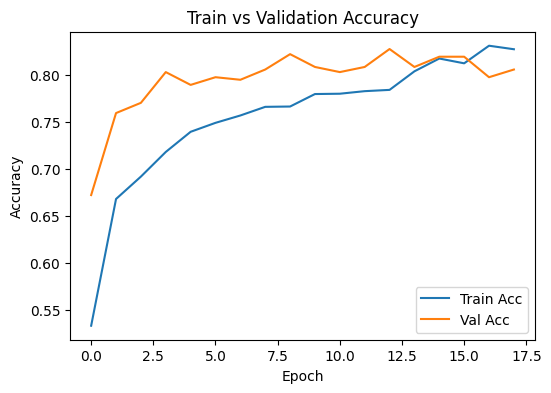

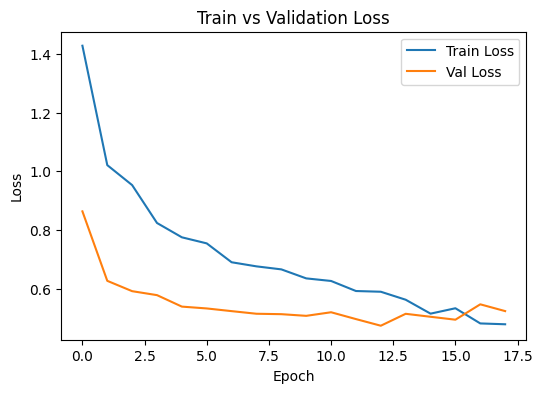

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(6,4))
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Train vs Validation Accuracy")
plt.show()

# Loss
plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Train vs Validation Loss")
plt.show()


23/23 ━━━━━━━━━━━━━━━━━━━━ 148s 6s/step
===== TEST SET METRICS =====
Accuracy           : 0.8142
Precision (macro)  : 0.6531
Recall (macro)     : 0.5946
F1-score (macro)   : 0.6041
AUC (macro OvR)    : 0.9186

Precision (weighted): 0.81
Recall (weighted)   : 0.8142
F1 (weighted)       : 0.8024


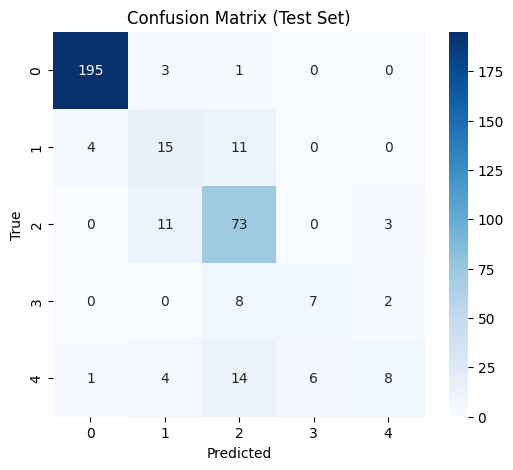


Classification Report:
              precision    recall  f1-score   support

           0     0.9750    0.9799    0.9774       199
           1     0.4545    0.5000    0.4762        30
           2     0.6822    0.8391    0.7526        87
           3     0.5385    0.4118    0.4667        17
           4     0.6154    0.2424    0.3478        33

    accuracy                         0.8142       366
   macro avg     0.6531    0.5946    0.6041       366
weighted avg     0.8100    0.8142    0.8024       366



In [ ]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 1️⃣ Predict on TEST data
# ===============================
y_prob = best_model.predict(test_data, verbose=1)
y_pred = np.argmax(y_prob, axis=1)
y_true = test_data.classes   # ground truth labels

# ===============================
# 2️⃣ Core metrics
# ===============================
acc  = accuracy_score(y_true, y_pred)
prec_macro = precision_score(y_true, y_pred, average="macro")
rec_macro  = recall_score(y_true, y_pred, average="macro")
f1_macro   = f1_score(y_true, y_pred, average="macro")

prec_weighted = precision_score(y_true, y_pred, average="weighted")
rec_weighted  = recall_score(y_true, y_pred, average="weighted")
f1_weighted   = f1_score(y_true, y_pred, average="weighted")

# ===============================
# 3️⃣ ROC–AUC (OvR, macro)
# ===============================
y_true_bin = label_binarize(y_true, classes=[0,1,2,3,4])
auc_macro = roc_auc_score(y_true_bin, y_prob, average="macro", multi_class="ovr")

# ===============================
# 4️⃣ Print metrics
# ===============================
print("===== TEST SET METRICS =====")
print(f"Accuracy           : {acc:.4f}")
print(f"Precision (macro)  : {prec_macro:.4f}")
print(f"Recall (macro)     : {rec_macro:.4f}")
print(f"F1-score (macro)   : {f1_macro:.4f}")
print(f"AUC (macro OvR)    : {auc_macro:.4f}")
print()
print("Precision (weighted):", round(prec_weighted,4))
print("Recall (weighted)   :", round(rec_weighted,4))
print("F1 (weighted)       :", round(f1_weighted,4))

# ===============================
# 5️⃣ Confusion Matrix (plot)
# ===============================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[0,1,2,3,4],
            yticklabels=[0,1,2,3,4])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Test Set)")
plt.show()

# ===============================
# 6️⃣ Full classification report
# ===============================
print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))


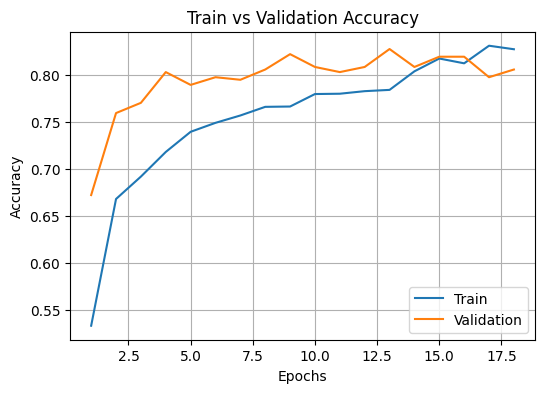

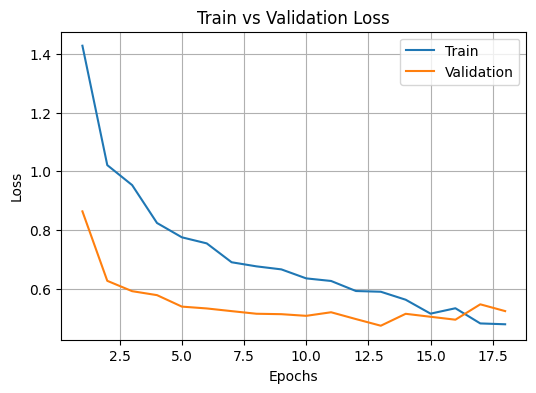

Skipping Train vs Validation AUC (metric not found)
Skipping Train vs Validation Precision (metric not found)
Skipping Train vs Validation Recall (metric not found)


In [ ]:
import matplotlib.pyplot as plt

# ===============================
# Get history dict
# ===============================
hist = history.history
epochs = range(1, len(hist["loss"]) + 1)

# ===============================
# Helper function
# ===============================
def plot_metric(train_key, val_key, title, ylabel):
    if train_key not in hist or val_key not in hist:
        print(f"Skipping {title} (metric not found)")
        return
    plt.figure(figsize=(6,4))
    plt.plot(epochs, hist[train_key], label="Train")
    plt.plot(epochs, hist[val_key], label="Validation")
    plt.xlabel("Epochs")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# ===============================
# 1️⃣ Accuracy
# ===============================
plot_metric("accuracy", "val_accuracy",
            "Train vs Validation Accuracy",
            "Accuracy")

# ===============================
# 2️⃣ Loss
# ===============================
plot_metric("loss", "val_loss",
            "Train vs Validation Loss",
            "Loss")

# ===============================
# 3️⃣ AUC
# ===============================
plot_metric("auc", "val_auc",
            "Train vs Validation AUC",
            "AUC")

# ===============================
# 4️⃣ Precision
# ===============================
plot_metric("precision", "val_precision",
            "Train vs Validation Precision",
            "Precision")

# ===============================
# 5️⃣ Recall
# ===============================
plot_metric("recall", "val_recall",
            "Train vs Validation Recall",
            "Recall")


**Data prep + severity label**

In [ ]:
import pandas as pd

# Load CSVs
train_df = pd.read_csv("/content/drive/MyDrive/CVPR/DATA_RAW/train_1.csv")
val_df   = pd.read_csv("/content/drive/MyDrive/CVPR/DATA_RAW/valid.csv")
test_df  = pd.read_csv("/content/drive/MyDrive/CVPR/DATA_RAW/test.csv")

# Filename column (IMPORTANT)
train_df["filename"] = train_df["id_code"].astype(str) + ".png"
val_df["filename"]   = val_df["id_code"].astype(str) + ".png"
test_df["filename"]  = test_df["id_code"].astype(str) + ".png"

# Severity score (continuous target)
train_df["severity"] = train_df["diagnosis"] / 4.0
val_df["severity"]   = val_df["diagnosis"] / 4.0
test_df["severity"]  = test_df["diagnosis"] / 4.0

train_df.head()


,id_code,diagnosis,filename,severity
0,1ae8c165fd53,2,1ae8c165fd53.png,0.50
1,1b329a127307,1,1b329a127307.png,0.25
2,1b32e1d775ea,4,1b32e1d775ea.png,1.00
3,1b3647865779,0,1b3647865779.png,0.00
4,1b398c0494d1,0,1b398c0494d1.png,0.00


In [ ]:
import pandas as pd

train_df = pd.read_csv("/content/drive/MyDrive/CVPR/DATA_RAW/train_1.csv")
val_df   = pd.read_csv("/content/drive/MyDrive/CVPR/DATA_RAW/valid.csv")
test_df  = pd.read_csv("/content/drive/MyDrive/CVPR/DATA_RAW/test.csv")

# MUST columns check
print(train_df.columns)


Index(['id_code', 'diagnosis'], dtype='object')


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224,224)
BATCH = 16

train_gen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.1
)

val_gen = ImageDataGenerator(rescale=1./255)


In [ ]:
def multitask_generator(df, img_dir, datagen, shuffle=True):
    base_gen = datagen.flow_from_dataframe(
        dataframe=df,
        directory=img_dir,
        x_col="filename",
        y_col=None,
        target_size=IMG_SIZE,
        class_mode=None,
        batch_size=BATCH,
        shuffle=shuffle
    )

    while True:
        X = next(base_gen)
        idx = base_gen.index_array
        y_class = df.iloc[idx]["diagnosis"].values
        y_sev   = df.iloc[idx]["severity"].values

        yield X, {
            "class_output": y_class,
            "severity_output": y_sev
        }


In [ ]:
TRAIN_DIR = "/content/drive/MyDrive/CVPR/DATA_RAW/train_images/train_images"
VAL_DIR   = "/content/drive/MyDrive/CVPR/DATA_RAW/val_images/val_images"
TEST_DIR  = "/content/drive/MyDrive/CVPR/DATA_RAW/test_images/test_images"

train_data = multitask_generator(train_df, TRAIN_DIR, train_gen, shuffle=True)
val_data   = multitask_generator(val_df,   VAL_DIR,   val_gen,   shuffle=False)
test_data  = multitask_generator(test_df,  TEST_DIR,  val_gen,   shuffle=False)


In [ ]:
# ADD filename column
train_df["filename"] = train_df["id_code"].astype(str) + ".png"
val_df["filename"]   = val_df["id_code"].astype(str) + ".png"
test_df["filename"]  = test_df["id_code"].astype(str) + ".png"

# Sanity check
print(train_df.head())


        id_code  diagnosis          filename
0  1ae8c165fd53          2  1ae8c165fd53.png
1  1b329a127307          1  1b329a127307.png
2  1b32e1d775ea          4  1b32e1d775ea.png
3  1b3647865779          0  1b3647865779.png
4  1b398c0494d1          0  1b398c0494d1.png


In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)


In [ ]:
def multitask_generator(df, img_dir, datagen, batch_size=16, shuffle=True):

    base_gen = datagen.flow_from_dataframe(
        dataframe=df,
        directory=img_dir,
        x_col="filename",
        y_col="diagnosis",
        target_size=(224, 224),
        class_mode="sparse",
        batch_size=batch_size,
        shuffle=shuffle
    )

    while True:   # 🔴 THIS IS MANDATORY
        X, y_class = next(base_gen)

        # severity = class / 4.0  (base-paper logic)
        y_severity = y_class / 4.0

        yield X, {
            "class_output": y_class,
            "severity_output": y_severity
        }


In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)

train_data = multitask_generator(
    train_df,
    "/content/drive/MyDrive/CVPR/DATA_RAW/train_images/train_images",
    train_datagen,
    batch_size=16,
    shuffle=True
)

val_data = multitask_generator(
    val_df,
    "/content/drive/MyDrive/CVPR/DATA_RAW/val_images/val_images",
    val_datagen,
    batch_size=16,
    shuffle=False
)


In [ ]:
train_df["diagnosis"] = train_df["diagnosis"].astype(str)
val_df["diagnosis"]   = val_df["diagnosis"].astype(str)
test_df["diagnosis"]  = test_df["diagnosis"].astype(str)


In [ ]:
train_data = multitask_generator(
    train_df,
    "/content/drive/MyDrive/CVPR/DATA_RAW/train_images/train_images",
    train_datagen,
    batch_size=16,
    shuffle=True
)

val_data = multitask_generator(
    val_df,
    "/content/drive/MyDrive/CVPR/DATA_RAW/val_images/val_images",
    val_datagen,
    batch_size=16,
    shuffle=False
)


In [ ]:
X_batch, y_batch = next(train_data)

print("Image batch shape:", X_batch.shape)
print("Class labels:", y_batch["class_output"][:5])
print("Severity:", y_batch["severity_output"][:5])


Found 2930 validated image filenames belonging to 5 classes.
Image batch shape: (16, 224, 224, 3)
Class labels: [2. 2. 2. 0. 0.]
Severity: [0.5 0.5 0.5 0.  0. ]


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

IMG_SIZE = (224, 224, 3)

# ===== Backbone =====
base_model = DenseNet201(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=IMG_SIZE
)
base_model.trainable = False  # Stage-1: freeze backbone

# ===== Multi-task heads =====
inputs = Input(shape=IMG_SIZE)
x = base_model(inputs, training=False)

x = Dense(512, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

x = Dense(256, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

# Classification head (0–4)
class_output = Dense(
    5, activation="softmax", name="class_output"
)(x)

# Severity head (0.0–1.0)
severity_output = Dense(
    1, activation="linear", name="severity_output"
)(x)

model = Model(
    inputs=inputs,
    outputs={
        "class_output": class_output,
        "severity_output": severity_output
    }
)

# ===== Compile =====
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss={
        "class_output": tf.keras.losses.SparseCategoricalCrossentropy(),
        "severity_output": tf.keras.losses.MeanSquaredError(),
    },
    loss_weights={
        "class_output": 1.0,
        "severity_output": 0.3,   # class > severity (stable start)
    },
    metrics={
        "class_output": ["accuracy"],
        "severity_output": ["mae"],
    }
)

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet201         │ (None, 1920)      │ 18,321,984 │ input_layer_3[0]… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 512)       │    983,552 │ densenet201[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │    131,328 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_output        │ (None, 5)         │      1,285 │ dropout_3[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ severity_output     │ (None, 1)         │        257 │ dropout_3[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 19,441,478 (74.16 MB)

 Trainable params: 1,117,958 (4.26 MB)

 Non-trainable params: 18,323,520 (69.90 MB)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "/content/drive/MyDrive/CVPR/best_multitask_densenet201.keras",
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),

    loss={
        "class_output": "sparse_categorical_crossentropy",
        "severity_output": "mse"
    },

    metrics={
        "class_output": ["accuracy"],   # 🔴 MUST
        "severity_output": ["mae"]
    }
)


In [ ]:
tf.keras.callbacks.EarlyStopping(
    monitor="val_class_output_accuracy",
    mode="max",
    patience=6,
    restore_best_weights=True
)


In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    steps_per_epoch=len(train_df)//16,
    validation_steps=len(val_df)//16,
    epochs=30,
    callbacks=callbacks
)


Epoch 1/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - class_output_accuracy: 0.2901 - class_output_loss: 2.1981 - loss: 5.1604 - severity_output_loss: 2.9623 - severity_output_mae: 1.3763Found 366 validated image filenames belonging to 5 classes.

Epoch 1: val_loss improved from inf to 1.50446, saving model to /content/drive/MyDrive/CVPR/best_multitask_densenet201.keras
183/183 ━━━━━━━━━━━━━━━━━━━━ 2002s 11s/step - class_output_accuracy: 0.2906 - class_output_loss: 2.1962 - loss: 5.1572 - severity_output_loss: 2.9611 - severity_output_mae: 1.3760 - val_class_output_accuracy: 0.6761 - val_class_output_loss: 0.9493 - val_loss: 1.5045 - val_severity_output_loss: 0.5552 - val_severity_output_mae: 0.6129 - learning_rate: 1.0000e-04
Epoch 2/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - class_output_accuracy: 0.5842 - class_output_loss: 1.2529 - loss: 3.5129 - severity_output_loss: 2.2600 - severity_output_mae: 1.2011
Epoch 2: val_loss improved from 1.50446 to 1.16718, saving model to /content

In [ ]:
MODEL_PATH = "/content/drive/MyDrive/CVPR/best_multitask_densenet201.keras"


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model

model = load_model(MODEL_PATH)
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet201         │ (None, 1920)      │ 18,321,984 │ input_layer_3[0]… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 512)       │    983,552 │ densenet201[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │    131,328 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_output        │ (None, 5)         │      1,285 │ dropout_3[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ severity_output     │ (None, 1)         │        257 │ dropout_3[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 21,677,396 (82.69 MB)

 Trainable params: 1,117,958 (4.26 MB)

 Non-trainable params: 18,323,520 (69.90 MB)

 Optimizer params: 2,235,918 (8.53 MB)

In [ ]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.densenet import preprocess_input

IMG_SIZE = (224, 224)
TEST_DIR = "/content/drive/MyDrive/CVPR/DATA_RAW/test_images/test_images"

X_test = []

for fname in test_df["filename"]:
    path = os.path.join(TEST_DIR, fname)
    img = load_img(path, target_size=IMG_SIZE)
    img = img_to_array(img)
    img = preprocess_input(img)
    X_test.append(img)

X_test = np.array(X_test)

print("X_test shape:", X_test.shape)


X_test shape: (366, 224, 224, 3)


In [ ]:
print(test_df.columns)


Index(['id_code', 'diagnosis', 'filename'], dtype='object')


In [ ]:
# Make sure diagnosis is numeric
test_df["diagnosis"] = test_df["diagnosis"].astype(int)

# Create severity proxy
test_df["severity"] = test_df["diagnosis"] / 4.0


In [ ]:
print(test_df[["diagnosis", "severity"]].head())
print(test_df.dtypes)


   diagnosis  severity
0          0       0.0
1          2       0.5
2          4       1.0
3          0       0.0
4          0       0.0
id_code       object
diagnosis      int64
filename      object
severity     float64
dtype: object


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def multitask_test_generator(df, img_dir, batch_size=16):
    n = len(df)
    while True:
        for i in range(0, n, batch_size):
            batch_df = df.iloc[i:i+batch_size]

            X = []
            for fname in batch_df["filename"]:
                img = load_img(f"{img_dir}/{fname}", target_size=(224,224))
                img = img_to_array(img) / 255.0
                X.append(img)

            X = np.array(X)

            y_class = batch_df["diagnosis"].values
            y_sev   = batch_df["severity"].values

            yield X, {
                "class_output": y_class,
                "severity_output": y_sev
            }


In [ ]:
TEST_IMG_DIR = "/content/drive/MyDrive/CVPR/DATA_RAW/test_images/test_images"

test_data = multitask_test_generator(
    test_df,
    TEST_IMG_DIR,
    batch_size=16
)


In [ ]:
y_pred_class, y_pred_severity = model.predict(
    test_data,
    steps=len(test_df)//16 + 1,
    verbose=1
)


23/23 ━━━━━━━━━━━━━━━━━━━━ 130s 5s/step


In [ ]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

IMG_SIZE = (224, 224)

def load_test_images(df, img_dir):
    X = []
    for fname in df["filename"]:
        img = load_img(
            os.path.join(img_dir, fname),
            target_size=IMG_SIZE
        )
        img = img_to_array(img) / 255.0
        X.append(img)
    return np.array(X)

X_test = load_test_images(
    test_df,
    "/content/drive/MyDrive/CVPR/DATA_RAW/test_images/test_images"
)

print(X_test.shape)  # (366, 224, 224, 3)


(366, 224, 224, 3)


In [ ]:
y_pred = model.predict(X_test, batch_size=16, verbose=1)


23/23 ━━━━━━━━━━━━━━━━━━━━ 108s 4s/step


In [ ]:
print(type(y_pred))
print(y_pred)


<class 'dict'>
{'class_output': array([[9.9244905e-01, 3.3984960e-03, 6.9013925e-04, 2.3743401e-03,
        1.0879465e-03],
       [4.6215006e-05, 3.0095669e-02, 8.8589370e-01, 4.8411451e-02,
        3.5553072e-02],
       [1.4006461e-04, 4.9043559e-03, 6.1145955e-01, 2.9893601e-01,
        8.4560163e-02],
       ...,
       [3.3277643e-06, 7.3257694e-03, 8.7414986e-01, 2.9287376e-02,
        8.9233585e-02],
       [9.8901296e-01, 4.4884724e-03, 5.5807224e-04, 4.2080935e-03,
        1.7325145e-03],
       [3.3992075e-04, 4.0519904e-02, 8.1503457e-01, 3.1692427e-02,
        1.1241315e-01]], dtype=float32), 'severity_output': array([[ 1.21342428e-01],
       [ 6.77277446e-01],
       [ 5.80347061e-01],
       [ 7.98550546e-02],
       [ 2.44388282e-01],
       [ 2.25514501e-01],
       [ 6.79138064e-01],
       [ 4.46338892e-01],
       [ 1.29593849e-01],
       [ 3.41020435e-01],
       [ 2.53079951e-01],
       [ 1.94657013e-01],
       [ 7.76681423e-01],
       [ 1.20957807e-01],
    

In [ ]:
y_pred["class_output"]      # shape (366, 5)
y_pred["severity_output"]   # shape (366, 1)


array([[ 1.21342428e-01],
       [ 6.77277446e-01],
       [ 5.80347061e-01],
       [ 7.98550546e-02],
       [ 2.44388282e-01],
       [ 2.25514501e-01],
       [ 6.79138064e-01],
       [ 4.46338892e-01],
       [ 1.29593849e-01],
       [ 3.41020435e-01],
       [ 2.53079951e-01],
       [ 1.94657013e-01],
       [ 7.76681423e-01],
       [ 1.20957807e-01],
       [ 7.94429183e-01],
       [ 1.67006612e-01],
       [-2.80137688e-01],
       [ 3.08416963e-01],
       [ 1.57375202e-01],
       [ 1.07412589e+00],
       [-2.21789777e-02],
       [ 1.98594511e-01],
       [ 6.16543651e-01],
       [ 4.31981355e-01],
       [ 4.68787104e-01],
       [ 3.52606773e-01],
       [-4.94884178e-02],
       [-1.91932961e-01],
       [ 1.31293893e-01],
       [-5.10900915e-02],
       [ 6.94995403e-01],
       [ 1.25230789e-01],
       [ 5.43186069e-01],
       [ 3.24262261e-01],
       [ 7.27546453e-01],
       [ 3.17887634e-01],
       [ 7.25670338e-01],
       [ 7.13760376e-01],
       [ 3.1

In [ ]:
import numpy as np

y_pred_class = y_pred["class_output"]          # (N, 5)
y_pred_severity = y_pred["severity_output"].squeeze()  # (N,)

y_true_class = test_df["diagnosis"].values
y_true_severity = test_df["severity"].values

print(y_pred_class.shape, y_pred_severity.shape)


(366, 5) (366,)


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    confusion_matrix
)

# Predicted labels
y_pred_labels = np.argmax(y_pred_class, axis=1)

# Accuracy
acc = accuracy_score(y_true_class, y_pred_labels)

# Precision / Recall / F1
prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true_class, y_pred_labels, average="macro"
)

# AUC (OvR)
auc_ovr = roc_auc_score(
    y_true_class,
    y_pred_class,
    multi_class="ovr"
)

print(f"Accuracy        : {acc:.4f}")
print(f"Macro Precision : {prec_macro:.4f}")
print(f"Macro Recall    : {rec_macro:.4f}")
print(f"Macro F1        : {f1_macro:.4f}")
print(f"AUC (OvR)       : {auc_ovr:.4f}")


Accuracy        : 0.8142
Macro Precision : 0.6765
Macro Recall    : 0.5454
Macro F1        : 0.5540
AUC (OvR)       : 0.9220


In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_true_severity, y_pred_severity)
print(f"Severity MAE : {mae:.4f}")


Severity MAE : 0.1872


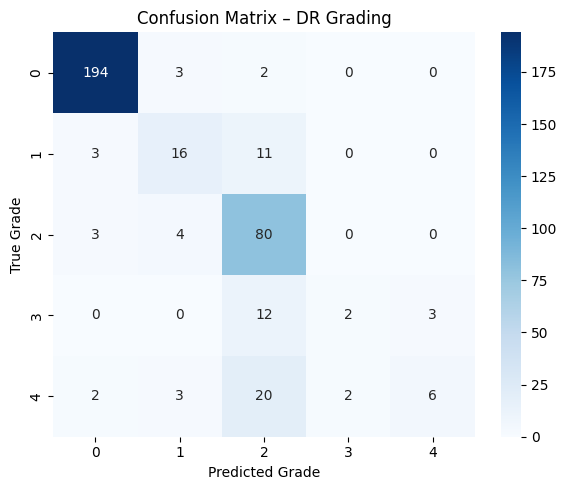

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true_class, y_pred_labels)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[0,1,2,3,4],
    yticklabels=[0,1,2,3,4]
)
plt.xlabel("Predicted Grade")
plt.ylabel("True Grade")
plt.title("Confusion Matrix – DR Grading")
plt.tight_layout()
plt.show()


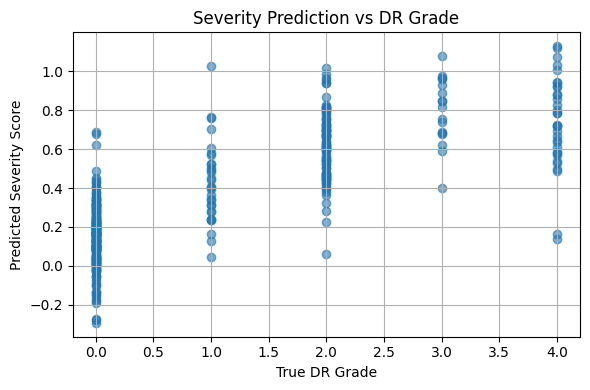

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(y_true_class, y_pred_severity, alpha=0.6)
plt.xlabel("True DR Grade")
plt.ylabel("Predicted Severity Score")
plt.title("Severity Prediction vs DR Grade")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
y_pred_sev_raw = y_pred["severity_output"].squeeze()
y_true_sev = test_df["severity"].values


In [ ]:
y_pred_sev_clip = np.clip(y_pred_sev_raw, 0.0, 1.0)


In [ ]:
from sklearn.metrics import mean_absolute_error

mae_raw  = mean_absolute_error(y_true_sev, y_pred_sev_raw)
mae_clip = mean_absolute_error(y_true_sev, y_pred_sev_clip)

print("MAE (raw) :", round(mae_raw, 4))
print("MAE (clip):", round(mae_clip, 4))


MAE (raw) : 0.1872
MAE (clip): 0.1787


In [ ]:
from scipy.stats import spearmanr, pearsonr

sp_corr, _ = spearmanr(y_true_sev, y_pred_sev_clip)
pe_corr, _ = pearsonr(y_true_sev, y_pred_sev_clip)

print("Spearman ρ:", round(sp_corr, 3))
print("Pearson r :", round(pe_corr, 3))


Spearman ρ: 0.803
Pearson r : 0.796


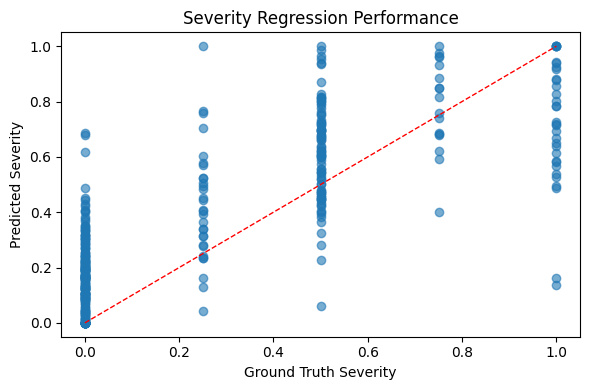

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(y_true_sev, y_pred_sev_clip, alpha=0.6)
plt.plot([0,1], [0,1], 'r--', linewidth=1)
plt.xlabel("Ground Truth Severity")
plt.ylabel("Predicted Severity")
plt.title("Severity Regression Performance")
plt.tight_layout()
plt.show()


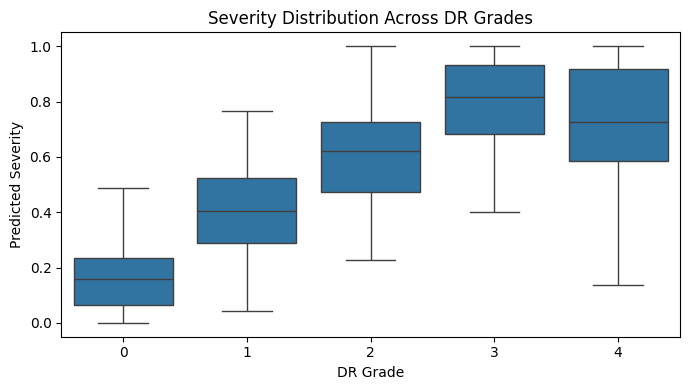

In [ ]:
import seaborn as sns

df_plot = test_df.copy()
df_plot["pred_severity"] = y_pred_sev_clip

plt.figure(figsize=(7,4))
sns.boxplot(
    x="diagnosis",
    y="pred_severity",
    data=df_plot,
    showfliers=False
)
plt.xlabel("DR Grade")
plt.ylabel("Predicted Severity")
plt.title("Severity Distribution Across DR Grades")
plt.tight_layout()
plt.show()


In [ ]:
def get_patient_id(id_code):
    return id_code[:10]   # common prefix trick (used in DR papers)

test_df["patient_id"] = test_df["id_code"].apply(get_patient_id)


In [ ]:
import numpy as np

y_pred_class = np.argmax(y_pred["class_output"], axis=1)
y_pred_sev   = np.clip(y_pred["severity_output"].squeeze(), 0, 1)

test_df["pred_class"] = y_pred_class
test_df["pred_severity"] = y_pred_sev


In [ ]:
pairs = []

for pid, grp in test_df.groupby("patient_id"):
    if len(grp) == 2:   # exactly two eyes
        e1, e2 = grp.iloc[0], grp.iloc[1]
        pairs.append({
            "patient_id": pid,
            "asym_severity": abs(e1["pred_severity"] - e2["pred_severity"]),
            "asym_class": abs(e1["pred_class"] - e2["pred_class"]),
            "max_grade": max(e1["diagnosis"], e2["diagnosis"])
        })

pair_df = pd.DataFrame(pairs)
print(pair_df.head())


Empty DataFrame
Columns: []
Index: []


In [ ]:
df = train_df.copy()


In [ ]:
df["patient_id"] = df["id_code"].str[:8]


In [ ]:
STEPS = int(np.ceil(len(test_df) / BATCH_SIZE))

y_pred = model.predict(
    test_data,
    steps=STEPS,
    verbose=1
)


23/23 ━━━━━━━━━━━━━━━━━━━━ 119s 5s/step


In [ ]:
y_pred_class = y_pred["class_output"]        # (N, 5)
y_pred_severity = y_pred["severity_output"].squeeze()  # (N,)


In [ ]:
test_df["pred_severity"] = y_pred_severity
test_df["pred_class"] = np.argmax(y_pred_class, axis=1)

test_df["patient_id"] = test_df["id_code"].str[:-1]   # adjust if needed


In [ ]:
test_df[["id_code", "patient_id"]].head()


,id_code,patient_id
0,e4dcca36ceb4,e4dcca36ceb
1,e4e343eaae2a,e4e343eaae2
2,e4f12411fd85,e4f12411fd8
3,e50b0174690d,e50b0174690
4,e5197d77ec68,e5197d77ec6


In [ ]:
asym_df = (
    test_df
    .groupby("patient_id")
    .agg({
        "pred_severity": lambda x: np.abs(x.max() - x.min()),
        "pred_class":    lambda x: np.abs(x.max() - x.min())
    })
    .reset_index()
    .rename(columns={
        "pred_severity": "severity_asymmetry",
        "pred_class": "grade_asymmetry"
    })
)


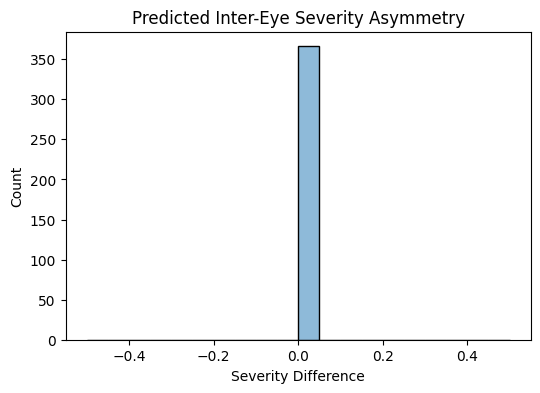

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.histplot(asym_df["severity_asymmetry"], bins=20, kde=True)
plt.title("Predicted Inter-Eye Severity Asymmetry")
plt.xlabel("Severity Difference")
plt.ylabel("Count")
plt.show()
